In [28]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.metrics import f1_score, make_scorer, accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import seaborn as sns
from matplotlib import pyplot as plt


from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import cohen_kappa_score

Return the fully merged datasets

In [29]:
def get_dfs():
    train_df = pd.read_csv("dataset/train.csv")
    test_df = pd.read_csv("dataset/test.csv")
    complaints_df = pd.read_csv("dataset/chief_complaints.csv")
    histsory_df = pd.read_csv("dataset/patient_history.csv")
    patient_info_df = complaints_df.merge(
        histsory_df,
        on="patient_id",
        how="outer"
    )

    train_df.drop(columns=["chief_complaint_system"], inplace=True)
    test_df.drop(columns=["chief_complaint_system"], inplace=True)

    train_full_df = train_df.merge(
        patient_info_df,
        on="patient_id",
        how="left"
    )

    test_full_df = test_df.merge(
        patient_info_df,
        on="patient_id",
        how="left"
    )

    train_full_df.to_csv("dataset/train_dataset.csv", index=False)
    test_full_df.to_csv("dataset/test_dataset.csv", index=False)

    train_df = train_full_df
    test_df = test_full_df
    return train_df, test_df

Produce some debug files to see the distrubution of nans and values withing each field

In [30]:
def get_df_info(train_df):
    of = open("DBG/categorical_describe.txt", "w")
    of.write(train_df.describe(include=[object]).to_string())
    of.close()

    of = open("DBG/numerical_describe.txt", "w")
    of.write(train_df.describe(exclude=[object]).to_string())
    of.close()

    of = open("DBG/nans_per_col.txt", "w")
    of.write(train_df.isna().sum(axis=0).to_string())
    of.close()

    nans_per_row = train_df.isna().sum(axis=1)
    mean = nans_per_row.mean()
    std = nans_per_row.std()

    print(f"the average number of missing values per row is: {mean}, with a standard deviation of {std}")

Decide wether or not you want to generalize the dispositions. If set to true, write the generalization you want to perform

In [31]:
GENERALIZE_DIPOSITION = True

generalization = {
    "discharged": "low",
    "observation": "medium",
    "admitted": "high",
    "transferred": "high",
    "deceased": "high",
    "lwbs": "low",
    "lama": "medium"
}



def generalize_disposition(disposition):
    if (not GENERALIZE_DIPOSITION):
        return disposition

    return generalization[disposition]


def replace_disposition_with_index(disposition, disp_to_index):
    return disp_to_index[disposition]

Bernoulli Naive Bayes for text encoding

In [32]:
def plain_text(text):
    new_text = ""
    
    for char in text:
        # unkown character, simply put space
        if not (65 <= ord(char) <= 90 or 97 <= ord(char) <= 122):
                new_text = new_text + " "
                
        elif (65 <= ord(char) <= 90 or 97 <= ord(char) <= 122) and not open:
            new_text = new_text + char
            
    return new_text


def word_frequency_in_disposition(text, label, diz):
    diz_appeared = {}
    fields = text.split(" ")
    
    for (i, w) in enumerate(fields):
        #se in questo testo non avevo ancora mai visto questa parola
        if (i < len(fields)-2):
            string = w + " " + fields[i+1] + " " + fields[i+2]
            if (not string in diz_appeared.keys()):
                #segno che adesso l'ho incontrata, e la prossima volta la skippo
                diz_appeared[string] = 1

                #aumento di 1 il numero di volte che l'ho incontrata in testi di questa disposition
                #.get(w, 0) ritorna 0 se quella chiave non esisteva, altrimenti ritorna il valore associatogli
                diz[label][string] = diz[label].get(string, 0) + 1
                
                
        if (i < len(fields)-1):
            string = w + " " + fields[i+1]
            if (not string in diz_appeared.keys()):
                #segno che adesso l'ho incontrata, e la prossima volta la skippo
                diz_appeared[string] = 1

                #aumento di 1 il numero di volte che l'ho incontrata in testi di questa disposition
                #.get(w, 0) ritorna 0 se quella chiave non esisteva, altrimenti ritorna il valore associatogli
                diz[label][string] = diz[label].get(string, 0) + 1
            
        string = w
        if (not string in diz_appeared.keys()):
            #segno che adesso l'ho incontrata, e la prossima volta la skippo
            diz_appeared[string] = 1

            #aumento di 1 il numero di volte che l'ho incontrata in testi di questa disposition
            #.get(w, 0) ritorna 0 se quella chiave non esisteva, altrimenti ritorna il valore associatogli
            diz[label][string] = diz[label].get(string, 0) + 1
    
    
    
def fill_dict(df, label, diz):
    df['chief_complaint_raw'].apply(word_frequency_in_disposition, label = label, diz = diz)
    
    
def vectorize(text, diz, dispositions, occurrences):
    l = [0 for d in dispositions]
    
    p = 0.0
    alpha = 1
    
    
    
    fields = text.split(" ")

    for (i, w) in enumerate(fields):
        if i < len(fields)-2:
            string = w + " " + fields[i+1] + " " + fields[i+2]
            
            #per ogni parola del testo, valuto quanto è 'associata' probabilisticamente parlando ad una disposition
            for d in range(len(dispositions)):
                count = diz[d].get(string, 0)
                p = (count + alpha) / (occurrences[d] + (2 * alpha)) #aggiungo alpha a numeratore per non calcolare mai log(0), aggiungo 2alpha a denominatore perché si
                l[d] += np.log(p)
                
                
        if i < len(fields)-1:
            string = w + " " + fields[i+1]
            
            #per ogni parola del testo, valuto quanto è 'associata' probabilisticamente parlando ad una disposition
            for d in range(len(dispositions)):
                count = diz[d].get(string, 0)
                p = (count + alpha) / (occurrences[d] + (2 * alpha)) #aggiungo alpha a numeratore per non calcolare mai log(0), aggiungo 2alpha a denominatore perché si
                l[d] += np.log(p)
        
            
        string = w
        #per ogni parola del testo, valuto quanto è 'associata' probabilisticamente parlando ad una disposition
        for d in range(len(dispositions)):
            count = diz[d].get(string, 0)
            p = (count + alpha) / (occurrences[d] + (2 * alpha)) #aggiungo alpha a numeratore per non calcolare mai log(0), aggiungo 2alpha a denominatore perché si
            l[d] += np.log(p)
    
    
    arr = np.array(l)
    
    mean_v = np.mean(arr)

    relative = arr - mean_v
    
    max_v = np.max(arr)
    min_v = np.min(arr)
    std_v = np.std(arr)
    

    new_feat = [max_v, min_v, std_v]

    
    res = np.concatenate((arr, relative))
    res = np.concatenate((res, np.array(new_feat)))
    return res


def BNB(train_df, val_df, y_train_split, dispositions):
    counts = y_train_split.value_counts()
    disposition_occurences = [counts.get(d, 0) for d in range(len(dispositions))]
    
    [print(f"For disposition <{dispositions[i]}> we have <{disposition_occurences[i]}> occurences") for i in range(len(dispositions))]
        
    
    # produce dictionary word_occurrences_per_disposition[disposition_id][word]
    word_occurrences_per_disposition = []
    for i in range(len(dispositions)):
        mask = (y_train_split == i)
        sub_df = train_df.loc[mask]
        word_occurrences_per_disposition.append({})
        fill_dict(sub_df, i, word_occurrences_per_disposition)
    
    
    column_names = [f"vectorized_{i}" for i in range(len(dispositions) * 2 + 3)]
    
    series = train_df['chief_complaint_raw']
    new_cols = series.apply(vectorize, diz = word_occurrences_per_disposition, dispositions = dispositions, occurrences = disposition_occurences).apply(pd.Series)
    new_cols.columns = column_names
    train_df = train_df.drop(columns=['chief_complaint_raw']).join(new_cols)
    
    series = val_df['chief_complaint_raw']
    new_cols = series.apply(vectorize, diz = word_occurrences_per_disposition, dispositions = dispositions, occurrences = disposition_occurences).apply(pd.Series)
    new_cols.columns = column_names
    val_df = val_df.drop(columns=['chief_complaint_raw']).join(new_cols)
    
    
    return train_df, val_df

Time features encoding / feature extraction

In [33]:
def time_features(df):
    # --- 1. Hour cyclical encoding ---
    df["hour_sin"] = np.sin(2 * np.pi * df["arrival_hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["arrival_hour"] / 24)

    # --- 2. Day encoding ---
    day_map = {
        "Monday": 0, "Tuesday": 1, "Wednesday": 2,
        "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
    }
    df["day_num"] = df["arrival_day"].map(day_map)

    df["day_sin"] = np.sin(2 * np.pi * df["day_num"] / 7)
    df["day_cos"] = np.cos(2 * np.pi * df["day_num"] / 7)

    # --- 3. Month cyclical encoding ---
    df["month_sin"] = np.sin(2 * np.pi * df["arrival_month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["arrival_month"] / 12)

    # --- 4. Season one-hot encoding ---
    df = pd.get_dummies(df, columns=["arrival_season"], prefix="season")

    # --- Drop original columns ---
    df = df.drop(columns=["arrival_hour", "arrival_day", "arrival_month", "day_num"])

    return df

Feature extraction for clinical features

In [34]:
def add_clinical_features(df):
    df = df.copy()

    # I manually manage null values in different places so I prefer them to -1s
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].replace(-1, np.nan)

    
    df["unstable"] = (
        (df["shock_index"].fillna(0) > 1) |
        (df["spo2"].fillna(100) < 92) |
        (df["gcs_total"].fillna(15) < 15)
    ).astype(int)

    

    
    df["sepsis_like"] = (
        (
            (df["temperature_c"].fillna(36) > 38) |
            (df["temperature_c"].fillna(36) < 36)
        ) &
        (
            (df["heart_rate"].fillna(0) > 90) |
            (df["respiratory_rate"].fillna(0) > 20)
        )
    ).astype(int)

    
    df["frail"] = (
        (df["age"].fillna(0) > 75) &
        (df["num_comorbidities"].fillna(0) >= 3)
    ).astype(int)

    df["polypharmacy"] = (df["num_active_medications"].fillna(0) >= 5).astype(int)

   
    df["cvd_burden"] = (
        df["hx_hypertension"].fillna(0) +
        df["hx_heart_failure"].fillna(0) +
        df["hx_atrial_fibrillation"].fillna(0) +
        df["hx_coronary_artery_disease"].fillna(0)
    )

    df["resp_burden"] = (
        df["hx_asthma"].fillna(0) +
        df["hx_copd"].fillna(0)
    )

    df["neuro_burden"] = (
        df["hx_dementia"].fillna(0) +
        df["hx_epilepsy"].fillna(0)
    )

    df["psych_burden"] = (
        df["hx_depression"].fillna(0) +
        df["hx_anxiety"].fillna(0)
    )

    df["immuno_risk"] = (
        (df["hx_hiv"].fillna(0) == 1) |
        (df["hx_immunosuppressed"].fillna(0) == 1) |
        (df["hx_malignancy"].fillna(0) == 1)
    ).astype(int)

    
        
        
      
    # Infection estimate
    df["infection"] = (
        (df["temperature_c"].fillna(36.5) >= 37.5) |
        (df["temperature_c"].fillna(36.5) < 36) |
        (df["chief_complaint_raw"].fillna("").str.contains("fever", case=False)) | 
        (df["chief_complaint_raw"].fillna("").str.contains("sti ", case=False)) | 
        (df["chief_complaint_raw"].fillna("").str.contains("uti ", case=False)) | 
        (df["chief_complaint_raw"].fillna("").str.contains("urti ", case=False)) | 
        (df["chief_complaint_raw"].fillna("").str.contains("infect", case=False)) |
        (df["heart_rate"].fillna(75) >= 90)
    )
    
    # qSOFA
    df["qSOFA"] = (
        (
            (df["respiratory_rate"].fillna(17) >= 22).astype(int) + 
            (df["gcs_total"].fillna(15) < 15).astype(int) + 
            (df["systolic_bp"].fillna(120) <= 100).astype(int) +
            (df["infection"]).astype(int)
        ) >= 2
    )
    
    
    # Age Shock Index
    df["age_shock_index"] = (
        (df["shock_index"].fillna(0.6) * df["age"].fillna(40))
    )
    
    A = df["gcs_total"]
    B = df["systolic_bp"]
    C = df["respiratory_rate"]

    res = pd.Series(0, index=A.index)


    # RTS
    # punteggi per A
    res[(A >= 4) & (A <= 5)] += 1
    res[(A >= 6) & (A <= 8)] += 2
    res[(A >= 9) & (A <= 12)] += 3
    res[(A >= 13) & (A <= 15)] += 4

    # punteggi per B
    res[(B >= 1) & (B <= 49)] += 1
    res[(B >= 50) & (B <= 75)] += 2
    res[(B >= 76) & (B <= 89)] += 3
    res[(B > 89)] += 4

    # punteggi per C
    res[(C >= 1) & (C <= 5)] += 1
    res[(C >= 6) & (C <= 9)] += 2
    res[(C > 29)] += 3
    res[(C >= 10) & (C <= 29)] += 4

    df["rts"] = res
    
    
    # MSI
    df["MSI"] = (
        (df["heart_rate"].fillna(70) / df["mean_arterial_pressure"].fillna(100))
    )
    
    
    # Age BMI
    df["age_bmi"] = (
        (df["age"].fillna(40) * df["bmi"].fillna(21))
    )
    
    
    
    hx_cols = [col for col in df.columns if col.startswith("hx_")]

    df["worrying_history"] = (
        df[hx_cols]
        .fillna(0)
        .astype(int)
        .sum(axis=1)
    )
    
    return df

Current pipeline
- It would probably be wiser to manually change null values the same way I did in the `add_clinical_features` function, with appropriate 'normal' values, rather than a random negative integer, because it might be misinterpreted

In [35]:
def pipeline(train_df):
    # generalize disposition and change 'disposition' to numbers instead of strings
    dispositions = ['discharged', 'transferred', 'observation', 'admitted', 'deceased', 'lwbs', 'lama']
    train_df['disposition'] = train_df['disposition'].apply(generalize_disposition)
    
    if (GENERALIZE_DIPOSITION):
        dispositions = set()
        for key in generalization:
            dispositions.add(generalization[key])

        dispositions = [disp for disp in dispositions]
        print(f"CURRENT DISPOSITIONS: {dispositions}\n")
    
    disp_to_index = {}
    for i in range(len(dispositions)):
        disp_to_index[dispositions[i]] = i

    train_df['disposition'] = train_df['disposition'].apply(replace_disposition_with_index, disp_to_index = disp_to_index)


    
    
    
    
    
    # get cleaned df and associated y
    y_train = train_df['disposition']
    train_df = train_df.drop(columns=['patient_id','disposition', "ed_los_hours", "triage_acuity"])
    
    # reformat text
    train_df['chief_complaint_raw'] = train_df['chief_complaint_raw'].apply(plain_text)
    train_df = add_clinical_features(train_df)
    
    # split
    train_df, val_df, y_train_split, y_val = train_test_split(train_df, y_train, train_size=0.8, random_state=42, stratify=y_train)

    
    
    
    
    
    
    # perform textual encodings
    train_df, val_df = BNB(train_df, val_df, y_train_split, dispositions)
    
    
    
    
    
    # extract time features
    train_df = time_features(train_df)
    val_df = time_features(val_df)
    
    
    

    # setup preprocessing
    categoricals = [field for field in train_df.columns if train_df.dtypes[field] == object]
    numericals = [field for field in train_df.columns if train_df.dtypes[field] != object]
    

    preprocessor = ColumnTransformer(
        transformers = [
            (
                "cat",
                Pipeline(
                    [
                        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
                    ]
                ),
                categoricals
            ),
            (
                "num",
                Pipeline(
                    [
                        ("imp", SimpleImputer(strategy="constant", fill_value=-1000)),
                    ]
                ),
                numericals
            )
        ],
        remainder = "drop"
    )
    
    
    
    
    
    

    
    
    # preprocess

    print(f"starting preprocessing...")

    X_train_pp = preprocessor.fit_transform(train_df)
    X_val_pp = preprocessor.transform(val_df)

    print(f"final dimensionality: {X_train_pp.shape}")






    # validate
    
    # set to true if the model you are using has feature importances
    feature_imp = True
    clf = RandomForestClassifier(
        n_estimators = 1000,
        criterion = 'entropy',
        max_depth = None,
        min_samples_split = 4,
        min_samples_leaf = 1,
        max_features = 'sqrt',
        n_jobs = -1,
        random_state = 42,
        class_weight="balanced"
    )
    

    print(f"starting fitting...")
    clf.fit(X_train_pp, y_train_split)

    print(f"fitting done, starting predicting...")
    y_pred = clf.predict(X_val_pp)

    print("\nAccuracy:", accuracy_score(y_val, y_pred))
    print("Macro F1:", f1_score(y_val, y_pred, average="macro"))
    print("Weighted F1:", f1_score(y_val, y_pred, average="weighted"))
    print("Quadratic Kappa:", cohen_kappa_score(y_val, y_pred, weights="quadratic"))

    print("\n\n\nClassification Report:")
    print(classification_report(y_val, y_pred))
    
    if feature_imp:
        importances = clf.feature_importances_
        feature_names = preprocessor.get_feature_names_out()

        feat_imp = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values(by='importance', ascending=False)

        feat_imp.to_csv("feature_importances.csv", index=False)









    # printing a confusion matrix
    labels = dispositions 

    cm = confusion_matrix(y_val, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", xticks_rotation=45)

    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    
    
    
    
    
    
    
    # ---- PRINTING ADMITTED THAT SHOULD'VE BEEN DISCHARGED
    if (GENERALIZE_DIPOSITION == False):
        mask = (y_pred == 3)
        mask2 = (y_val == 0)
        
        val_df[mask & mask2].to_csv("DBG/wrongly_admitted.csv", index=False)
        
        
        mask = (y_pred == 0)
        mask2 = (y_val == 3)
        
        val_df[mask & mask2].to_csv("DBG/wrongly_discharged.csv", index=False)

Main (entry point)

CURRENT DISPOSITIONS: ['medium', 'low', 'high']

For disposition <medium> we have <5681> occurences
For disposition <low> we have <34147> occurences
For disposition <high> we have <24172> occurences
starting preprocessing...
final dimensionality: (64000, 200)
starting fitting...
fitting done, starting predicting...

Accuracy: 0.6830625
Macro F1: 0.46516937372160455
Weighted F1: 0.6460142717380245
Quadratic Kappa: 0.319954343700635



Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1420
           1       0.68      0.86      0.76      8537
           2       0.68      0.59      0.63      6043

    accuracy                           0.68     16000
   macro avg       0.45      0.48      0.47     16000
weighted avg       0.62      0.68      0.65     16000



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

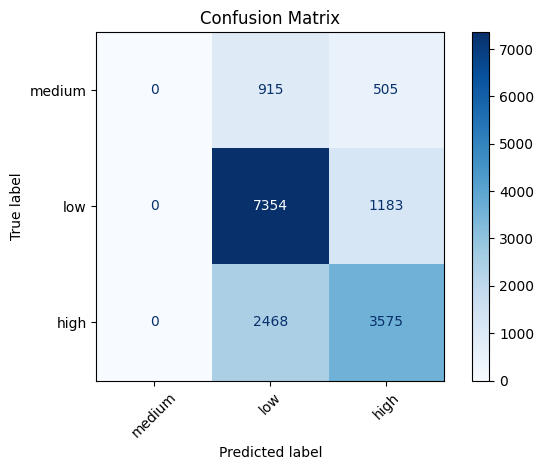

In [36]:
def main():
    train_df, test_df = get_dfs()
    pipeline(train_df)
    
    
    
main()